<a href="https://colab.research.google.com/github/tharak-bairneni/eda-assignment/blob/main/Retail_Sales_EDA_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Tharakbairneni

Title: Exploratory Data Analysis of Retail Sales Data

In [1]:
#Import Libraries & Generate Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)

data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)

print(df.shape)
df.head()

(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


Task 1 — Inspect & Handle Missing Values

In [2]:
#Print Shape
df.shape

(200, 6)

In [3]:
#Display Data Types
df.dtypes

,0
order_id,int64
city,object
category,object
order_value,float64
delivery_days,float64
rating,object


In [4]:
#Count Missing Values
df.isna().sum()

,0
order_id,0
city,0
category,0
order_value,14
delivery_days,10
rating,32


In [5]:
#Percentage of Missing Values
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent.round(2)

,0
order_id,0.0
city,0.0
category,0.0
order_value,7.0
delivery_days,5.0
rating,16.0


Task 2 — Summarize & Visualize

In [6]:
#Summary Statistics
df.describe()

,order_id,order_value,delivery_days
count,200.000000,186.000000,190.000000
mean,1100.500000,3707.134409,7.810526
std,57.879185,9238.438378,4.075465
min,1001.000000,204.000000,1.000000
25%,1050.750000,1512.000000,4.000000
50%,1100.500000,2934.000000,8.000000
75%,1150.250000,3987.500000,12.000000
max,1200.000000,95000.000000,14.000000


bservation 1:
The order_value column shows a very high maximum value compared to the 75th percentile, indicating the presence of extreme outliers.

Observation 2:
The delivery_days column appears relatively consistent with a smaller spread between minimum and maximum values compared to order_value.

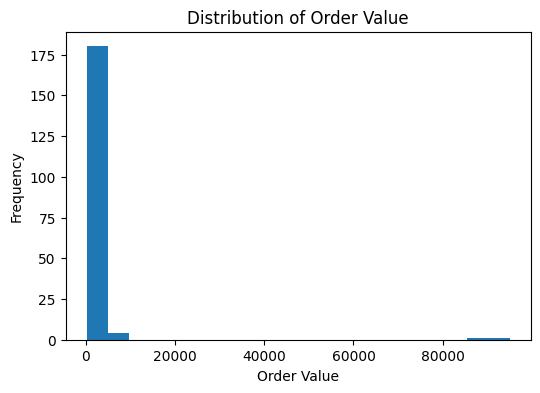

In [7]:
#Histogram of Order Value
plt.figure(figsize=(6,4))

plt.hist(df["order_value"].dropna(), bins=20)

plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")

plt.show()

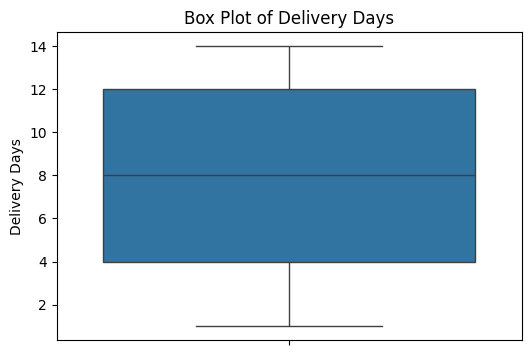

In [8]:
#Box Plot for Delivery Days
plt.figure(figsize=(6,4))

sns.boxplot(y=df["delivery_days"])

plt.title("Box Plot of Delivery Days")
plt.ylabel("Delivery Days")

plt.show()

Task 3 — Correlation Analysis

In [11]:
# Correlation Matrix
corr_matrix = df.corr(numeric_only=True)

corr_matrix

,order_id,order_value,delivery_days
order_id,1.000000,-0.095503,0.004858
order_value,-0.095503,1.000000,0.141660
delivery_days,0.004858,0.141660,1.000000


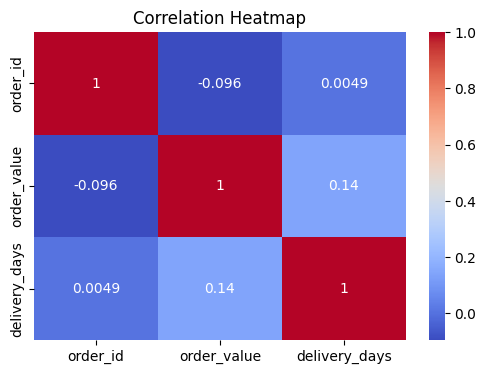

In [12]:
#Heatmap Visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

From the heatmap, the correlation between order_value and delivery_days appears to be weak, indicating that larger orders do not necessarily require longer delivery times.

All cells have been executed and the outputs are visible. This notebook performs a basic Exploratory Data Analysis to inspect dataset structure, identify missing values, visualize distributions, and analyze correlations between numerical variables.